In [334]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns 
color = sns.color_palette()
import sklearn.metrics as metrics
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [335]:
df=pd.read_csv(r'C:\Users\Anmol\Desktop\Credit_Risk_Data_CSV.csv')

In [336]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2058 entries, 0 to 2057
Data columns (total 58 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Co_Code                                           2058 non-null   int64  
 1   Co_Name                                           2058 non-null   object 
 2   Operating_Expense_Rate                            2058 non-null   float64
 3   RD_expense_rate                                   2058 non-null   float64
 4   Cash_flow_rate                                    2058 non-null   float64
 5   Interest_bearing_debt_interest_rate               2058 non-null   float64
 6   Tax_rate_A                                        2058 non-null   float64
 7   Cash_Flow_Per_Share                               1891 non-null   float64
 8   Per_Share_Net_profit_before_tax_Yuan_             2058 non-null   float64
 9   Realized_Sales_Gros

In [337]:
df.head()

,Co_Code,Co_Name,Operating_Expense_Rate,RD_expense_rate,Cash_flow_rate,Interest_bearing_debt_interest_rate,Tax_rate_A,Cash_Flow_Per_Share,Per_Share_Net_profit_before_tax_Yuan_,Realized_Sales_Gross_Profit_Growth_Rate,...,Cash_Flow_to_Equity,Current_Liability_to_Current_Assets,Liability_Assets_Flag,Total_assets_to_GNP_price,No_credit_Interval,DFL,Interest_Coverage_Ratio_Interest_expense_to_EBIT,Net_Income_Flag,Equity_to_Liability,Default
0,16974,Hind.Cables,8.820000e+09,0.000000e+00,0.462045,0.000352,0.001417,0.322558,0.194472,0.022074,...,0.310901,0.034913,0,0.028801,0.620927,0.026930,0.565744,1,0.015338,0
1,21214,Tata Tele. Mah.,9.380000e+09,4.230000e+09,0.460116,0.000716,0.000000,0.315520,0.161633,0.021902,...,0.314572,0.041653,0,0.006191,0.622513,0.026297,0.560741,1,0.029445,1
2,14852,ABG Shipyard,3.800000e+09,8.150000e+08,0.449893,0.000496,0.000000,0.299851,0.172554,0.022186,...,0.314777,0.033560,0,0.001095,0.623749,0.027276,0.566744,1,0.041718,0
3,2439,GTL,6.440000e+09,0.000000e+00,0.462731,0.000592,0.009313,0.319834,0.174738,0.027638,...,0.316974,0.016527,0,0.003749,0.622963,0.026988,0.565950,1,0.026956,0
4,23505,Bharati Defence,3.680000e+09,0.000000e+00,0.463117,0.000782,0.400243,0.325104,0.176546,0.022072,...,0.317729,0.034497,0,0.006595,0.624419,0.027498,0.567177,1,0.019900,0


In [338]:
shape = df.shape
print(shape)

(2058, 58)


In [339]:
df.describe()

,Co_Code,Operating_Expense_Rate,RD_expense_rate,Cash_flow_rate,Interest_bearing_debt_interest_rate,Tax_rate_A,Cash_Flow_Per_Share,Per_Share_Net_profit_before_tax_Yuan_,Realized_Sales_Gross_Profit_Growth_Rate,Operating_Profit_Growth_Rate,...,Cash_Flow_to_Equity,Current_Liability_to_Current_Assets,Liability_Assets_Flag,Total_assets_to_GNP_price,No_credit_Interval,DFL,Interest_Coverage_Ratio_Interest_expense_to_EBIT,Net_Income_Flag,Equity_to_Liability,Default
count,2058.000000,2.058000e+03,2.058000e+03,2058.000000,2.058000e+03,2058.000000,1891.000000,2058.000000,2058.000000,2058.000000,...,2058.000000,2044.000000,2058.000000,2.058000e+03,2058.000000,2058.000000,2058.000000,2058.0,2058.000000,2058.000000
mean,17572.113217,2.052389e+09,1.208634e+09,0.465243,1.113022e+07,0.114777,0.319986,0.176967,0.022761,0.848108,...,0.314629,0.039352,0.003401,2.779397e+07,0.623686,0.027852,0.565435,1.0,0.042529,0.106900
std,21892.886518,3.252624e+09,2.144568e+09,0.022663,9.042595e+07,0.152446,0.015300,0.030157,0.021701,0.004589,...,0.012780,0.047978,0.058236,4.717714e+08,0.011631,0.013839,0.011535,0.0,0.059525,0.309061
min,4.000000,1.000260e-04,0.000000e+00,0.000000,0.000000e+00,0.000000,0.169449,0.000000,0.004282,0.736430,...,0.000000,0.000000,0.000000,0.000000e+00,0.408682,0.012845,0.172065,1.0,0.003946,0.000000
25%,3674.000000,1.578727e-04,0.000000e+00,0.460099,2.760280e-04,0.000000,0.314989,0.166604,0.022058,0.847974,...,0.312783,0.021775,0.000000,9.124052e-04,0.623327,0.026776,0.565158,1.0,0.020408,0.000000
50%,6240.000000,3.330330e-04,1.994130e-04,0.463445,4.540450e-04,0.037099,0.320648,0.175642,0.022100,0.848039,...,0.314642,0.032652,0.000000,2.479550e-03,0.623750,0.026815,0.565315,1.0,0.028460,0.000000
75%,24280.750000,4.110000e+09,1.550000e+09,0.468069,6.630660e-04,0.216191,0.325918,0.185885,0.022152,0.848115,...,0.316546,0.043947,0.000000,7.004449e-03,0.624045,0.027029,0.566232,1.0,0.043433,0.000000
max,72493.000000,9.980000e+09,9.980000e+09,1.000000,9.900000e+08,0.999696,0.462227,0.792348,1.000000,1.000000,...,0.569231,1.000000,1.000000,9.820000e+09,0.956387,0.464388,0.666761,1.0,1.000000,1.000000


In [340]:
df.duplicated().sum()

0

In [341]:
# Missing Values check and Treatment
df.isnull().sum()

Co_Code                                               0
Co_Name                                               0
Operating_Expense_Rate                                0
RD_expense_rate                                       0
Cash_flow_rate                                        0
Interest_bearing_debt_interest_rate                   0
Tax_rate_A                                            0
Cash_Flow_Per_Share                                 167
Per_Share_Net_profit_before_tax_Yuan_                 0
Realized_Sales_Gross_Profit_Growth_Rate               0
Operating_Profit_Growth_Rate                          0
Continuous_Net_Profit_Growth_Rate                     0
Total_Asset_Growth_Rate                               0
Net_Value_Growth_Rate                                 0
Total_Asset_Return_Growth_Rate_Ratio                  0
Cash_Reinvestment_perc                                0
Current_Ratio                                         0
Quick_Ratio                                     

In [342]:
df1=df.dropna()

In [343]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1771 entries, 0 to 2057
Data columns (total 58 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Co_Code                                           1771 non-null   int64  
 1   Co_Name                                           1771 non-null   object 
 2   Operating_Expense_Rate                            1771 non-null   float64
 3   RD_expense_rate                                   1771 non-null   float64
 4   Cash_flow_rate                                    1771 non-null   float64
 5   Interest_bearing_debt_interest_rate               1771 non-null   float64
 6   Tax_rate_A                                        1771 non-null   float64
 7   Cash_Flow_Per_Share                               1771 non-null   float64
 8   Per_Share_Net_profit_before_tax_Yuan_             1771 non-null   float64
 9   Realized_Sales_Gros

In [344]:
df1.isnull().sum()

Co_Code                                             0
Co_Name                                             0
Operating_Expense_Rate                              0
RD_expense_rate                                     0
Cash_flow_rate                                      0
Interest_bearing_debt_interest_rate                 0
Tax_rate_A                                          0
Cash_Flow_Per_Share                                 0
Per_Share_Net_profit_before_tax_Yuan_               0
Realized_Sales_Gross_Profit_Growth_Rate             0
Operating_Profit_Growth_Rate                        0
Continuous_Net_Profit_Growth_Rate                   0
Total_Asset_Growth_Rate                             0
Net_Value_Growth_Rate                               0
Total_Asset_Return_Growth_Rate_Ratio                0
Cash_Reinvestment_perc                              0
Current_Ratio                                       0
Quick_Ratio                                         0
Interest_Expense_Ratio      

In [345]:
df1['Default'].value_counts()

0    1580
1     191
Name: Default, dtype: int64

In [346]:
# Checking proportion of default
df1.Default.sum() / len(df1.Default)

0.10784867306606437

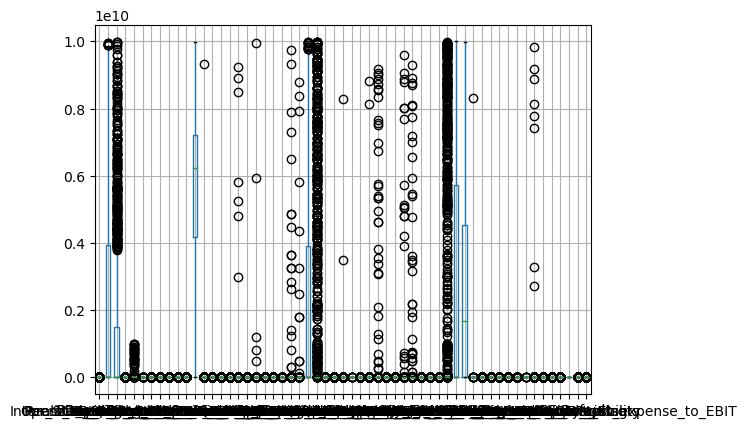

<Figure size 10000x5000 with 0 Axes>

In [347]:
df1.boxplot()
plt.figure (figsize = (100,50))
plt.show()



In [348]:
df2=df1.drop(columns=['Co_Code' , 'Co_Name'])

In [284]:
df2_X = df2.drop('Default', axis = 1)
df2_Y = df2['Default']

In [285]:
def remove_outlier(col):
    sorted(col)
    Q1,Q3=np.percentile(col,[25,75])
    IQR=Q3-Q1
    lower_range= Q1-(1.5 * IQR)
    upper_range= Q3+(1.5 * IQR)
    return lower_range, upper_range

In [286]:
   for column in df2_X.columns:
    lr,ur=remove_outlier(df2[column])
    df2_X[column]=np.where(df2_X[column]>ur,ur,df2_X[column])
    df2_X[column]=np.where(df2_X[column]<lr,lr,df2_X[column])

In [287]:
df3 = pd.concat([df2_X, df2_Y], axis = 1)

In [288]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1771 entries, 0 to 2057
Data columns (total 56 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Operating_Expense_Rate                            1771 non-null   float64
 1   RD_expense_rate                                   1771 non-null   float64
 2   Cash_flow_rate                                    1771 non-null   float64
 3   Interest_bearing_debt_interest_rate               1771 non-null   float64
 4   Tax_rate_A                                        1771 non-null   float64
 5   Cash_Flow_Per_Share                               1771 non-null   float64
 6   Per_Share_Net_profit_before_tax_Yuan_             1771 non-null   float64
 7   Realized_Sales_Gross_Profit_Growth_Rate           1771 non-null   float64
 8   Operating_Profit_Growth_Rate                      1771 non-null   float64
 9   Continuous_Net_Prof

In [349]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(X):

    # Calculating VIF
    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return(vif)

In [350]:
X = df3.drop('Default', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
6,Per_Share_Net_profit_before_tax_Yuan_,95.232466
19,Net_PBT_to_Paid_in_capital,94.450417
43,Cash_Flow_to_TA,43.963675
45,CFO_to_Assets,33.661770
30,Quick_Assets_to_CL,22.734497
32,Operating_Funds_to_Liability,22.152264
44,Cash_Flow_to_Liability,18.213164
2,Cash_flow_rate,17.253623
14,Current_Ratio,16.843041
25,NW_Turnover_Rate_times,16.312623


In [351]:
X = X.drop('Per_Share_Net_profit_before_tax_Yuan_', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
42,Cash_Flow_to_TA,43.932628
44,CFO_to_Assets,33.337167
29,Quick_Assets_to_CL,22.734189
31,Operating_Funds_to_Liability,22.121140
43,Cash_Flow_to_Liability,18.212812
2,Cash_flow_rate,17.253216
13,Current_Ratio,16.839839
24,NW_Turnover_Rate_times,16.310869
12,Cash_Reinvestment_perc,15.556318
19,Total_Asset_Turnover,15.344431


In [353]:
X = X.drop('Cash_Flow_to_TA', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
43,CFO_to_Assets,33.309204
29,Quick_Assets_to_CL,22.732324
31,Operating_Funds_to_Liability,22.112302
2,Cash_flow_rate,17.253710
13,Current_Ratio,16.833826
24,NW_Turnover_Rate_times,16.286449
12,Cash_Reinvestment_perc,15.445778
19,Total_Asset_Turnover,15.334592
14,Quick_Ratio,13.581787
5,Cash_Flow_Per_Share,11.071408


In [354]:
X = X.drop('CFO_to_Assets', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
29,Quick_Assets_to_CL,22.716596
31,Operating_Funds_to_Liability,19.726836
13,Current_Ratio,16.831989
2,Cash_flow_rate,16.665984
24,NW_Turnover_Rate_times,16.286504
19,Total_Asset_Turnover,15.328463
14,Quick_Ratio,13.579750
12,Cash_Reinvestment_perc,9.625068
5,Cash_Flow_Per_Share,9.420322
44,Current_Liability_to_Current_Assets,9.210107


In [356]:
X = X.drop('Quick_Assets_to_CL', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
30,Operating_Funds_to_Liability,19.560948
2,Cash_flow_rate,16.461338
24,NW_Turnover_Rate_times,16.251497
19,Total_Asset_Turnover,15.328397
13,Current_Ratio,14.566358
12,Cash_Reinvestment_perc,9.620478
5,Cash_Flow_Per_Share,9.410854
43,Current_Liability_to_Current_Assets,9.160873
18,Net_PBT_to_Paid_in_capital,8.419888
14,Quick_Ratio,8.323178


In [357]:
X = X.drop('Operating_Funds_to_Liability', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
24,NW_Turnover_Rate_times,16.020254
19,Total_Asset_Turnover,15.104659
13,Current_Ratio,14.339528
5,Cash_Flow_Per_Share,9.408151
42,Current_Liability_to_Current_Assets,9.155430
12,Cash_Reinvestment_perc,8.796602
18,Net_PBT_to_Paid_in_capital,8.392126
14,Quick_Ratio,8.232258
47,Interest_Coverage_Ratio_Interest_expense_to_EBIT,5.930323
49,Equity_to_Liability,5.532301


In [359]:
X = X.drop('NW_Turnover_Rate_times', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
13,Current_Ratio,14.298382
5,Cash_Flow_Per_Share,9.408127
41,Current_Liability_to_Current_Assets,9.154763
12,Cash_Reinvestment_perc,8.771462
18,Net_PBT_to_Paid_in_capital,8.365408
14,Quick_Ratio,8.150656
46,Interest_Coverage_Ratio_Interest_expense_to_EBIT,5.929645
48,Equity_to_Liability,5.527928
26,Quick_Assets_to_TA,5.425764
33,Total_income_to_Total_expense,5.260257


In [360]:
X = X.drop('Current_Ratio', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
5,Cash_Flow_Per_Share,9.407269
12,Cash_Reinvestment_perc,8.771015
17,Net_PBT_to_Paid_in_capital,8.354875
13,Quick_Ratio,6.456514
45,Interest_Coverage_Ratio_Interest_expense_to_EBIT,5.927501
25,Quick_Assets_to_TA,5.425429
40,Current_Liability_to_Current_Assets,5.390307
32,Total_income_to_Total_expense,5.255671
31,Retained_Earnings_to_Total_Assets,5.244775
39,Cash_Flow_to_Equity,5.226649


In [361]:
X = X.drop('Cash_Flow_Per_Share', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
16,Net_PBT_to_Paid_in_capital,8.039348
12,Quick_Ratio,6.418680
44,Interest_Coverage_Ratio_Interest_expense_to_EBIT,5.918429
24,Quick_Assets_to_TA,5.391152
39,Current_Liability_to_Current_Assets,5.389738
31,Total_income_to_Total_expense,5.255540
38,Cash_Flow_to_Equity,5.210994
30,Retained_Earnings_to_Total_Assets,5.188580
46,Equity_to_Liability,5.116310
37,Cash_Flow_to_Liability,5.014132


In [362]:
X = X.drop('Net_PBT_to_Paid_in_capital', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
12,Quick_Ratio,6.410197
43,Interest_Coverage_Ratio_Interest_expense_to_EBIT,5.873261
38,Current_Liability_to_Current_Assets,5.388510
23,Quick_Assets_to_TA,5.387180
37,Cash_Flow_to_Equity,5.187453
45,Equity_to_Liability,5.070953
36,Cash_Flow_to_Liability,4.978056
35,Fixed_Assets_to_Assets,4.735445
30,Total_income_to_Total_expense,4.415003
13,Interest_Expense_Ratio,4.367624


In [363]:
X = X.drop('Quick_Ratio', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
42,Interest_Coverage_Ratio_Interest_expense_to_EBIT,5.873061
36,Cash_Flow_to_Equity,5.187450
35,Cash_Flow_to_Liability,4.977845
22,Quick_Assets_to_TA,4.902847
34,Fixed_Assets_to_Assets,4.682695
29,Total_income_to_Total_expense,4.412334
12,Interest_Expense_Ratio,4.365305
37,Current_Liability_to_Current_Assets,4.256592
44,Equity_to_Liability,4.247071
23,Cash_to_TA,3.854003


In [364]:
X = X.drop('Interest_Coverage_Ratio_Interest_expense_to_EBIT', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
36,Cash_Flow_to_Equity,5.186428
35,Cash_Flow_to_Liability,4.974429
22,Quick_Assets_to_TA,4.890265
34,Fixed_Assets_to_Assets,4.681830
29,Total_income_to_Total_expense,4.412061
43,Equity_to_Liability,4.242837
37,Current_Liability_to_Current_Assets,4.230157
23,Cash_to_TA,3.849412
24,Cash_to_CL,3.835138
6,Operating_Profit_Growth_Rate,3.763330


In [365]:
X = X.drop('Cash_Flow_to_Equity', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
22,Quick_Assets_to_TA,4.888370
34,Fixed_Assets_to_Assets,4.681742
29,Total_income_to_Total_expense,4.409342
42,Equity_to_Liability,4.229990
36,Current_Liability_to_Current_Assets,4.229194
24,Cash_to_CL,3.780287
6,Operating_Profit_Growth_Rate,3.760986
23,Cash_to_TA,3.739174
28,Retained_Earnings_to_Total_Assets,3.688265
2,Cash_flow_rate,3.647359


In [366]:
X = X.drop('Quick_Assets_to_TA', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
33,Fixed_Assets_to_Assets,4.509202
28,Total_income_to_Total_expense,4.351112
41,Equity_to_Liability,4.227197
6,Operating_Profit_Growth_Rate,3.761078
23,Cash_to_CL,3.742107
27,Retained_Earnings_to_Total_Assets,3.681745
35,Current_Liability_to_Current_Assets,3.671597
2,Cash_flow_rate,3.640780
7,Continuous_Net_Profit_Growth_Rate,3.527120
22,Cash_to_TA,3.498894


In [367]:
X = X.drop('Fixed_Assets_to_Assets', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
28,Total_income_to_Total_expense,4.310840
40,Equity_to_Liability,4.223755
6,Operating_Profit_Growth_Rate,3.748171
23,Cash_to_CL,3.728656
27,Retained_Earnings_to_Total_Assets,3.677573
34,Current_Liability_to_Current_Assets,3.575230
2,Cash_flow_rate,3.551444
7,Continuous_Net_Profit_Growth_Rate,3.525404
22,Cash_to_TA,3.484846
10,Total_Asset_Return_Growth_Rate_Ratio,3.058859


In [368]:
X = X.drop('Total_income_to_Total_expense', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
39,Equity_to_Liability,4.206882
23,Cash_to_CL,3.728601
6,Operating_Profit_Growth_Rate,3.691131
33,Current_Liability_to_Current_Assets,3.574886
22,Cash_to_TA,3.479496
7,Continuous_Net_Profit_Growth_Rate,3.469704
2,Cash_flow_rate,3.445537
10,Total_Asset_Return_Growth_Rate_Ratio,3.019651
27,Retained_Earnings_to_Total_Assets,2.993832
15,Total_Asset_Turnover,2.982478


In [369]:
X = X.drop('Equity_to_Liability', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
6,Operating_Profit_Growth_Rate,3.687419
7,Continuous_Net_Profit_Growth_Rate,3.463631
23,Cash_to_CL,3.451280
22,Cash_to_TA,3.445665
33,Current_Liability_to_Current_Assets,3.442226
2,Cash_flow_rate,3.248750
10,Total_Asset_Return_Growth_Rate_Ratio,3.016959
27,Retained_Earnings_to_Total_Assets,2.987913
15,Total_Asset_Turnover,2.841970
5,Realized_Sales_Gross_Profit_Growth_Rate,2.742707


In [370]:
X = X.drop('Operating_Profit_Growth_Rate', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
22,Cash_to_CL,3.450418
21,Cash_to_TA,3.440519
32,Current_Liability_to_Current_Assets,3.436776
2,Cash_flow_rate,3.248779
26,Retained_Earnings_to_Total_Assets,2.981998
9,Total_Asset_Return_Growth_Rate_Ratio,2.976268
6,Continuous_Net_Profit_Growth_Rate,2.884584
14,Total_Asset_Turnover,2.841991
20,Allocation_rate_per_person,2.598967
15,Accounts_Receivable_Turnover,2.575177


In [371]:
X = X.drop('Cash_to_CL', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
31,Current_Liability_to_Current_Assets,3.241692
2,Cash_flow_rate,3.129728
9,Total_Asset_Return_Growth_Rate_Ratio,2.997081
25,Retained_Earnings_to_Total_Assets,2.981061
6,Continuous_Net_Profit_Growth_Rate,2.884022
14,Total_Asset_Turnover,2.664356
20,Allocation_rate_per_person,2.577479
15,Accounts_Receivable_Turnover,2.570819
19,Operating_profit_per_person,2.435675
10,Cash_Reinvestment_perc,2.412039


In [293]:
X = X.drop('Current_Liability_to_Current_Assets', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
42,Cash_Flow_to_TA,43.930772
44,CFO_to_Assets,33.337139
29,Quick_Assets_to_CL,22.612807
31,Operating_Funds_to_Liability,22.115374
43,Cash_Flow_to_Liability,18.210219
2,Cash_flow_rate,17.235217
24,NW_Turnover_Rate_times,16.309752
12,Cash_Reinvestment_perc,15.548236
19,Total_Asset_Turnover,15.297439
45,Cash_Flow_to_Equity,14.688065


In [372]:
X = X.drop('Total_Asset_Return_Growth_Rate_Ratio', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
30,Current_Liability_to_Current_Assets,3.240630
2,Cash_flow_rate,3.129100
24,Retained_Earnings_to_Total_Assets,2.979686
13,Total_Asset_Turnover,2.661642
19,Allocation_rate_per_person,2.577457
14,Accounts_Receivable_Turnover,2.570789
18,Operating_profit_per_person,2.424429
9,Cash_Reinvestment_perc,2.398226
10,Interest_Expense_Ratio,2.368744
15,Average_Collection_Days,2.332849


In [373]:
X = X.drop('Cash_flow_rate', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
29,Current_Liability_to_Current_Assets,3.096818
23,Retained_Earnings_to_Total_Assets,2.750498
12,Total_Asset_Turnover,2.602090
18,Allocation_rate_per_person,2.568828
13,Accounts_Receivable_Turnover,2.559426
9,Interest_Expense_Ratio,2.361924
17,Operating_profit_per_person,2.356258
33,DFL,2.326892
14,Average_Collection_Days,2.321784
7,Net_Value_Growth_Rate,2.111436


In [374]:
X = X.drop('Retained_Earnings_to_Total_Assets', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
28,Current_Liability_to_Current_Assets,3.069767
12,Total_Asset_Turnover,2.591038
13,Accounts_Receivable_Turnover,2.548009
18,Allocation_rate_per_person,2.532473
9,Interest_Expense_Ratio,2.360256
32,DFL,2.324798
14,Average_Collection_Days,2.321759
21,Inventory_to_CL,2.085809
19,Cash_to_TA,2.012499
23,Total_expense_to_Assets,1.993849


In [375]:
X = X.drop('Total_Asset_Turnover', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
27,Current_Liability_to_Current_Assets,3.040663
12,Accounts_Receivable_Turnover,2.513000
17,Allocation_rate_per_person,2.417786
9,Interest_Expense_Ratio,2.343038
31,DFL,2.318716
13,Average_Collection_Days,2.235053
20,Inventory_to_CL,2.039513
18,Cash_to_TA,2.000659
5,Continuous_Net_Profit_Growth_Rate,1.955931
16,Operating_profit_per_person,1.949410


In [376]:
X = X.drop('Accounts_Receivable_Turnover', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
26,Current_Liability_to_Current_Assets,3.020315
9,Interest_Expense_Ratio,2.339256
30,DFL,2.318784
16,Allocation_rate_per_person,2.310236
17,Cash_to_TA,1.999783
19,Inventory_to_CL,1.993850
5,Continuous_Net_Profit_Growth_Rate,1.955108
15,Operating_profit_per_person,1.939843
7,Net_Value_Growth_Rate,1.883260
21,Total_expense_to_Assets,1.852542


In [377]:
X = X.drop('Interest_Expense_Ratio', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
25,Current_Liability_to_Current_Assets,3.019629
15,Allocation_rate_per_person,2.306264
16,Cash_to_TA,1.997878
18,Inventory_to_CL,1.991546
5,Continuous_Net_Profit_Growth_Rate,1.951241
14,Operating_profit_per_person,1.921869
7,Net_Value_Growth_Rate,1.883254
20,Total_expense_to_Assets,1.851306
4,Realized_Sales_Gross_Profit_Growth_Rate,1.813198
9,Total_debt_to_Total_NW,1.735586


In [378]:
X = X.drop('Allocation_rate_per_person', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
24,Current_Liability_to_Current_Assets,3.019584
15,Cash_to_TA,1.997696
5,Continuous_Net_Profit_Growth_Rate,1.950868
17,Inventory_to_CL,1.930210
14,Operating_profit_per_person,1.891665
7,Net_Value_Growth_Rate,1.859309
4,Realized_Sales_Gross_Profit_Growth_Rate,1.812968
9,Total_debt_to_Total_NW,1.735546
19,Total_expense_to_Assets,1.704620
27,No_credit_Interval,1.517793


In [379]:
X = X.drop('Continuous_Net_Profit_Growth_Rate', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
23,Current_Liability_to_Current_Assets,3.019561
14,Cash_to_TA,1.996274
16,Inventory_to_CL,1.930262
13,Operating_profit_per_person,1.885266
6,Net_Value_Growth_Rate,1.779085
8,Total_debt_to_Total_NW,1.735511
18,Total_expense_to_Assets,1.682977
26,No_credit_Interval,1.515884
17,Long_term_Liability_to_CA,1.494169
10,Average_Collection_Days,1.439308


In [380]:
X = X.drop('Operating_profit_per_person', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
22,Current_Liability_to_Current_Assets,3.018822
13,Cash_to_TA,1.975626
15,Inventory_to_CL,1.917459
8,Total_debt_to_Total_NW,1.735254
6,Net_Value_Growth_Rate,1.645524
17,Total_expense_to_Assets,1.625186
25,No_credit_Interval,1.509169
16,Long_term_Liability_to_CA,1.492123
12,Fixed_Assets_Turnover_Frequency,1.423942
10,Average_Collection_Days,1.400485


In [381]:
X = X.drop('Cash_to_TA', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
21,Current_Liability_to_Current_Assets,2.754975
14,Inventory_to_CL,1.867307
8,Total_debt_to_Total_NW,1.731275
6,Net_Value_Growth_Rate,1.630467
16,Total_expense_to_Assets,1.559812
15,Long_term_Liability_to_CA,1.486942
24,No_credit_Interval,1.486031
12,Fixed_Assets_Turnover_Frequency,1.423090
9,Long_term_fund_suitability_ratio_A,1.394721
13,Inventory_to_WC,1.371760


In [382]:
X = X.drop('Net_Value_Growth_Rate', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
20,Current_Liability_to_Current_Assets,2.708734
13,Inventory_to_CL,1.835443
7,Total_debt_to_Total_NW,1.702045
15,Total_expense_to_Assets,1.490055
14,Long_term_Liability_to_CA,1.486842
23,No_credit_Interval,1.485995
11,Fixed_Assets_Turnover_Frequency,1.423024
8,Long_term_fund_suitability_ratio_A,1.389964
12,Inventory_to_WC,1.371393
9,Average_Collection_Days,1.347667


In [383]:
X = X.drop('Inventory_to_CL', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
19,Current_Liability_to_Current_Assets,2.239867
7,Total_debt_to_Total_NW,1.679850
13,Long_term_Liability_to_CA,1.482486
14,Total_expense_to_Assets,1.456175
11,Fixed_Assets_Turnover_Frequency,1.421621
22,No_credit_Interval,1.376873
8,Long_term_fund_suitability_ratio_A,1.364506
12,Inventory_to_WC,1.354169
21,Total_assets_to_GNP_price,1.346437
15,CA_Turnover_Rate,1.306350


In [384]:
X = X.drop('Total_expense_to_Assets', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
18,Current_Liability_to_Current_Assets,2.231952
7,Total_debt_to_Total_NW,1.674034
13,Long_term_Liability_to_CA,1.477978
11,Fixed_Assets_Turnover_Frequency,1.373143
21,No_credit_Interval,1.369083
8,Long_term_fund_suitability_ratio_A,1.364261
12,Inventory_to_WC,1.318025
14,CA_Turnover_Rate,1.278167
3,Tax_rate_A,1.266229
9,Average_Collection_Days,1.262872


In [385]:
X = X.drop('Long_term_Liability_to_CA', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
17,Current_Liability_to_Current_Assets,2.071669
7,Total_debt_to_Total_NW,1.673654
8,Long_term_fund_suitability_ratio_A,1.359521
20,No_credit_Interval,1.342564
12,Inventory_to_WC,1.317090
13,CA_Turnover_Rate,1.277699
11,Fixed_Assets_Turnover_Frequency,1.271749
3,Tax_rate_A,1.255204
14,Quick_Asset_Turnover_Rate,1.253766
9,Average_Collection_Days,1.252530


In [386]:
X = X.drop('No_credit_Interval', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
21,Net_Income_Flag,267294.132238
17,Current_Liability_to_Current_Assets,1.973105
7,Total_debt_to_Total_NW,1.668222
8,Long_term_fund_suitability_ratio_A,1.351708
13,CA_Turnover_Rate,1.274086
11,Fixed_Assets_Turnover_Frequency,1.269180
14,Quick_Asset_Turnover_Rate,1.253664
3,Tax_rate_A,1.243823
9,Average_Collection_Days,1.239737
20,DFL,1.228829


In [387]:
X = X.drop('Net_Income_Flag', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
12,Inventory_to_WC,54691.759804
4,Realized_Sales_Gross_Profit_Growth_Rate,50073.024608
20,DFL,10219.668603
6,Cash_Reinvestment_perc,793.751761
8,Long_term_fund_suitability_ratio_A,43.139051
17,Current_Liability_to_Current_Assets,8.894026
9,Average_Collection_Days,4.397018
7,Total_debt_to_Total_NW,4.394692
2,Interest_bearing_debt_interest_rate,3.756672
19,Total_assets_to_GNP_price,2.149214


In [388]:
X = X.drop('Inventory_to_WC', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
4,Realized_Sales_Gross_Profit_Growth_Rate,17365.464120
15,Cash_Flow_to_Liability,10099.837473
19,DFL,9345.970918
6,Cash_Reinvestment_perc,793.609722
8,Long_term_fund_suitability_ratio_A,43.094167
16,Current_Liability_to_Current_Assets,8.893802
5,Total_Asset_Growth_Rate,4.568583
9,Average_Collection_Days,4.375537
7,Total_debt_to_Total_NW,4.348998
2,Interest_bearing_debt_interest_rate,3.754637


In [389]:
X = X.drop('Realized_Sales_Gross_Profit_Growth_Rate', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
14,Cash_Flow_to_Liability,5755.812090
18,DFL,5129.846516
5,Cash_Reinvestment_perc,792.907965
7,Long_term_fund_suitability_ratio_A,42.899902
15,Current_Liability_to_Current_Assets,8.887287
4,Total_Asset_Growth_Rate,4.567840
8,Average_Collection_Days,4.362166
6,Total_debt_to_Total_NW,4.348998
2,Interest_bearing_debt_interest_rate,3.723249
17,Total_assets_to_GNP_price,2.125972


In [390]:
X = X.drop('Cash_Flow_to_Liability', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
17,DFL,794.209881
7,Long_term_fund_suitability_ratio_A,42.127308
14,Current_Liability_to_Current_Assets,8.859500
4,Total_Asset_Growth_Rate,4.523224
8,Average_Collection_Days,4.339249
6,Total_debt_to_Total_NW,4.337483
2,Interest_bearing_debt_interest_rate,3.723215
16,Total_assets_to_GNP_price,2.125504
11,CA_Turnover_Rate,2.114628
13,Cash_Turnover_Rate,1.946472


In [391]:
X = X.drop('DFL', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
5,Cash_Reinvestment_perc,68.927991
7,Long_term_fund_suitability_ratio_A,37.669163
14,Current_Liability_to_Current_Assets,8.840759
4,Total_Asset_Growth_Rate,4.515882
8,Average_Collection_Days,4.297997
6,Total_debt_to_Total_NW,4.148056
2,Interest_bearing_debt_interest_rate,3.716291
16,Total_assets_to_GNP_price,2.125498
11,CA_Turnover_Rate,2.111511
13,Cash_Turnover_Rate,1.946466


In [392]:
X = X.drop('Cash_Reinvestment_perc', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
6,Long_term_fund_suitability_ratio_A,9.300455
13,Current_Liability_to_Current_Assets,7.640434
4,Total_Asset_Growth_Rate,4.217186
5,Total_debt_to_Total_NW,4.145532
7,Average_Collection_Days,4.084918
2,Interest_bearing_debt_interest_rate,3.584313
15,Total_assets_to_GNP_price,2.124376
10,CA_Turnover_Rate,2.096538
12,Cash_Turnover_Rate,1.924578
11,Quick_Asset_Turnover_Rate,1.888103


In [393]:
X = X.drop('Long_term_fund_suitability_ratio_A', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
12,Current_Liability_to_Current_Assets,7.640297
5,Total_debt_to_Total_NW,4.083422
4,Total_Asset_Growth_Rate,3.859480
6,Average_Collection_Days,3.353405
2,Interest_bearing_debt_interest_rate,3.277200
14,Total_assets_to_GNP_price,2.035844
9,CA_Turnover_Rate,2.008521
11,Cash_Turnover_Rate,1.898202
10,Quick_Asset_Turnover_Rate,1.865230
3,Tax_rate_A,1.714168


In [394]:
X = X.drop('Total_Asset_Growth_Rate', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
11,Current_Liability_to_Current_Assets,7.442632
4,Total_debt_to_Total_NW,4.060931
5,Average_Collection_Days,3.187737
2,Interest_bearing_debt_interest_rate,3.187174
8,CA_Turnover_Rate,2.004152
13,Total_assets_to_GNP_price,1.968363
10,Cash_Turnover_Rate,1.852669
9,Quick_Asset_Turnover_Rate,1.849080
3,Tax_rate_A,1.648946
7,Fixed_Assets_Turnover_Frequency,1.626890


In [395]:
X = X.drop('Average_Collection_Days', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
10,Current_Liability_to_Current_Assets,7.158379
4,Total_debt_to_Total_NW,3.973236
2,Interest_bearing_debt_interest_rate,3.066902
7,CA_Turnover_Rate,1.994738
12,Total_assets_to_GNP_price,1.968115
9,Cash_Turnover_Rate,1.830103
8,Quick_Asset_Turnover_Rate,1.774200
6,Fixed_Assets_Turnover_Frequency,1.611327
3,Tax_rate_A,1.590063
0,Operating_Expense_Rate,1.498104


In [396]:
X = X.drop('Interest_bearing_debt_interest_rate', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
9,Current_Liability_to_Current_Assets,6.671158
3,Total_debt_to_Total_NW,3.963263
6,CA_Turnover_Rate,1.982982
11,Total_assets_to_GNP_price,1.956524
8,Cash_Turnover_Rate,1.812903
7,Quick_Asset_Turnover_Rate,1.774121
5,Fixed_Assets_Turnover_Frequency,1.608265
2,Tax_rate_A,1.542173
0,Operating_Expense_Rate,1.488897
4,Inventory_Turnover_Rate_times,1.416522


In [397]:
X = X.drop('Liability_Assets_Flag', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
9,Current_Liability_to_Current_Assets,6.671158
3,Total_debt_to_Total_NW,3.963263
6,CA_Turnover_Rate,1.982982
10,Total_assets_to_GNP_price,1.956524
8,Cash_Turnover_Rate,1.812903
7,Quick_Asset_Turnover_Rate,1.774121
5,Fixed_Assets_Turnover_Frequency,1.608265
2,Tax_rate_A,1.542173
0,Operating_Expense_Rate,1.488897
4,Inventory_Turnover_Rate_times,1.416522


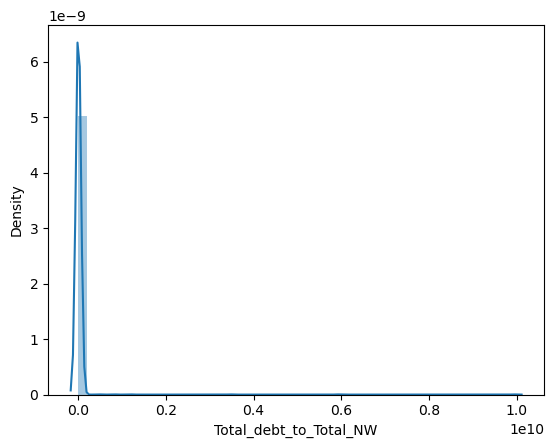

In [398]:
# Univariate Analysis
sns.distplot(df['Total_debt_to_Total_NW'])
plt.show() 

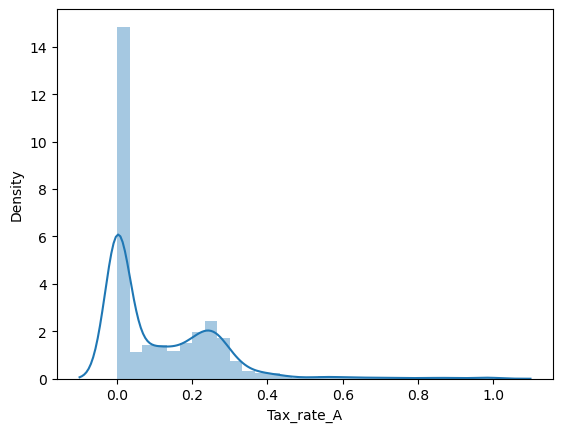

In [401]:
sns.distplot(df['Tax_rate_A'])
plt.show() 

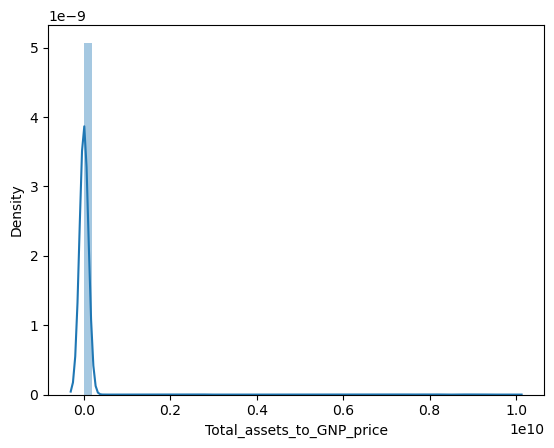

In [402]:
# Univariate Analysis
sns.distplot(df['Total_assets_to_GNP_price'])
plt.show() 

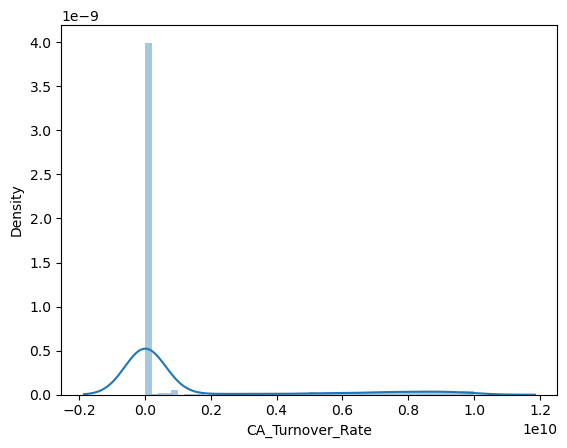

In [403]:
# Univariate Analysis
sns.distplot(df['CA_Turnover_Rate'])
plt.show() 

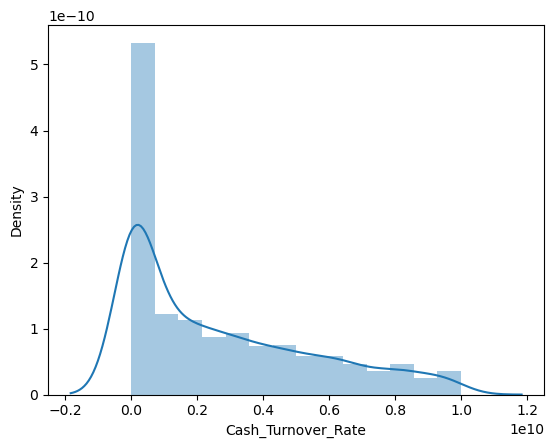

In [404]:
# Univariate Analysis
sns.distplot(df['Cash_Turnover_Rate'])
plt.show() 

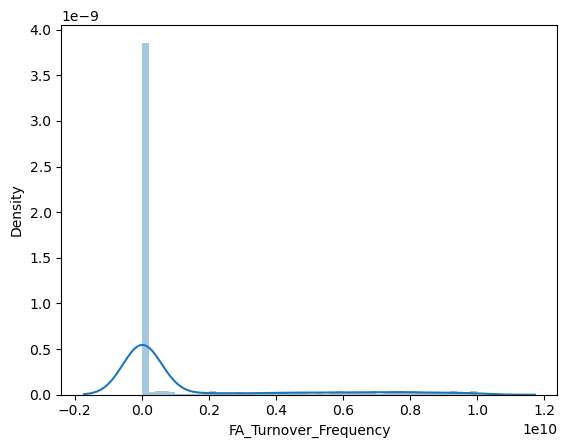

In [406]:
# Univariate Analysis
sns.distplot(df['FA_Turnover_Frequency'])
plt.show() 

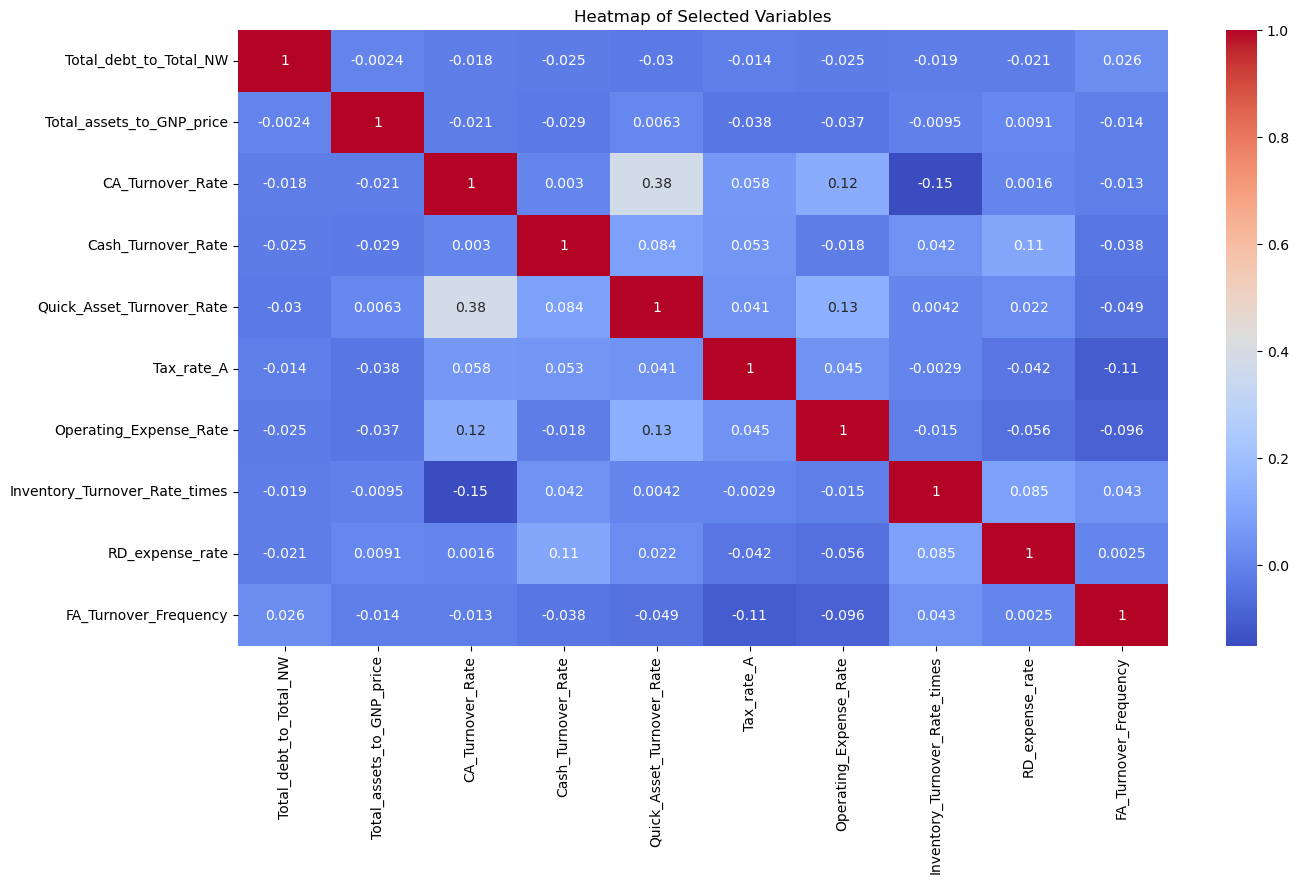

In [408]:
# Bivariate Analysis
selected_vars = df[['Total_debt_to_Total_NW','Total_assets_to_GNP_price','CA_Turnover_Rate',
                    'Cash_Turnover_Rate','Quick_Asset_Turnover_Rate','Tax_rate_A','Operating_Expense_Rate',
                    'Inventory_Turnover_Rate_times','RD_expense_rate','FA_Turnover_Frequency']]

# Creating a heatmap of the selected variables
plt.figure (figsize = (15,8))
sns.heatmap(selected_vars.corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap of Selected Variables')
plt.show()

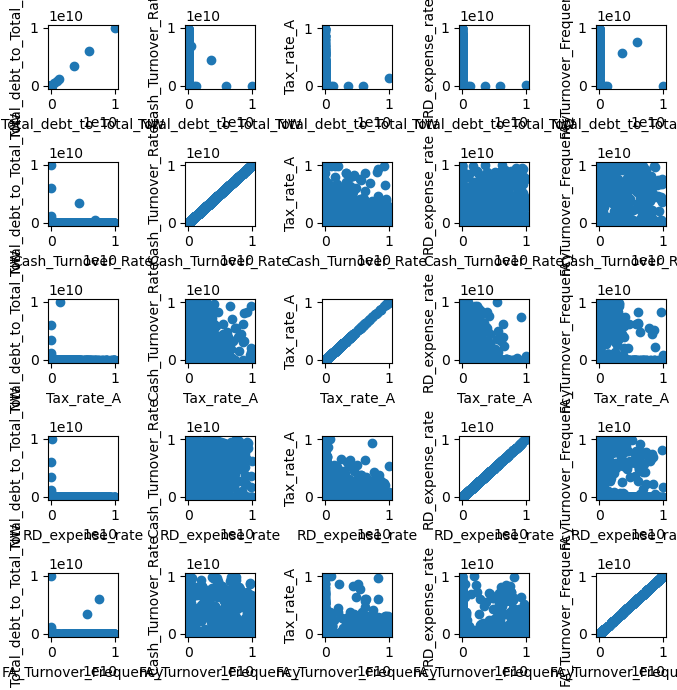

In [410]:
# Bivariate Analysis
# Creating a pairplot of the selected variables
selected_vars = df[['Total_debt_to_Total_NW','Cash_Turnover_Rate','Tax_rate_A','RD_expense_rate','FA_Turnover_Frequency']]
# Creating individual scatter plots for each pair of variables
fig, axs = plt.subplots(5, 5, figsize=(7, 7))
for i, col1 in enumerate(selected_vars.columns):
    for j, col2 in enumerate(selected_vars.columns):
        axs[i, j].scatter(selected_vars[col1], selected_vars[col2])
        axs[i, j].set_xlabel(col1)
        axs[i, j].set_ylabel(col2)

plt.tight_layout()
plt.show()

In [411]:
from sklearn.model_selection import train_test_split

In [412]:
y = df3['Default']

In [413]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)

In [414]:
df3_train = pd.concat([X_train, y_train], axis = 1)
df3_test = pd.concat([X_test, y_test], axis = 1)

In [415]:
import statsmodels.formula.api as SM

In [419]:
model_1 = SM.logit(formula = 'Default ~ Total_debt_to_Total_NW+\
Fixed_Assets_Turnover_Frequency+Total_assets_to_GNP_price+CA_Turnover_Rate+\
Tax_rate_A+Quick_Asset_Turnover_Rate+Operating_Expense_Rate+\
Inventory_Turnover_Rate_times+RD_expense_rate+Cash_Turnover_Rate', data=df3_train).fit()

Optimization terminated successfully.
         Current function value: 0.253198
         Iterations 9


In [420]:
model_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                Default   No. Observations:                 1186
Model:                          Logit   Df Residuals:                     1175
Method:                           MLE   Df Model:                           10
Date:                Sun, 07 Apr 2024   Pseudo R-squ.:                  0.2358
Time:                        12:07:39   Log-Likelihood:                -300.29
converged:                       True   LL-Null:                       -392.97
Covariance Type:            nonrobust   LLR p-value:                 1.817e-34
===================================================================================================
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -3.4568      0.321    -10.753      0.000      -4.087      -2.827
Total_debt_to_Total_NW            137.8416     13.950      9.881      0.000     110.500     165.184
Fixed_Assets_Turnover_Frequency    12.8393      6.935      1.851      0.064      -0.754      26.432
Total_assets_to_GNP_price          23.8338     19.829      1.202      0.229     -15.030      62.697
CA_Turnover_Rate                  100.1263    111.345      0.899      0.369    -118.106     318.359
Tax_rate_A                         -5.6204      1.240     -4.534      0.000      -8.050      -3.191
Quick_Asset_Turnover_Rate       -6.498e-11   3.52e-11     -1.844      0.065   -1.34e-10     4.1e-12
Operating_Expense_Rate          -3.126e-11   3.44e-11     -0.908      0.364   -9.88e-11    3.62e-11
Inventory_Turnover_Rate_times    3.309e-11   3.68e-11      0.900      0.368    -3.9e-11    1.05e-10
RD_expense_rate                  1.833e-10   7.66e-11      2.393      0.017    3.31e-11    3.33e-10
Cash_Turnover_Rate              -1.418e-10    4.4e-11     -3.222      0.001   -2.28e-10   -5.55e-11
===================================================================================================
"""

In [422]:
# Current Asset Turnover Rate and Quick Asset Turnover Rate are insignificant variables. Therefore, we will eliminate them
model_2 = SM.logit(formula = 'Default ~ Total_debt_to_Total_NW+\
Fixed_Assets_Turnover_Frequency+Total_assets_to_GNP_price+Tax_rate_A+Operating_Expense_Rate+\
Inventory_Turnover_Rate_times+RD_expense_rate+Cash_Turnover_Rate', data=df3_train).fit()

Optimization terminated successfully.
         Current function value: 0.254779
         Iterations 8


In [423]:
model_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                Default   No. Observations:                 1186
Model:                          Logit   Df Residuals:                     1177
Method:                           MLE   Df Model:                            8
Date:                Sun, 07 Apr 2024   Pseudo R-squ.:                  0.2311
Time:                        12:08:38   Log-Likelihood:                -302.17
converged:                       True   LL-Null:                       -392.97
Covariance Type:            nonrobust   LLR p-value:                 4.762e-35
===================================================================================================
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -3.4581      0.311    -11.119      0.000      -4.068      -2.848
Total_debt_to_Total_NW            137.0878     13.687     10.016      0.000     110.261     163.915
Fixed_Assets_Turnover_Frequency    13.6700      6.890      1.984      0.047       0.166      27.174
Total_assets_to_GNP_price          24.0889     19.833      1.215      0.225     -14.783      62.961
Tax_rate_A                         -5.6433      1.236     -4.564      0.000      -8.066      -3.220
Operating_Expense_Rate          -4.258e-11    3.4e-11     -1.252      0.210   -1.09e-10    2.41e-11
Inventory_Turnover_Rate_times    2.564e-11   3.63e-11      0.706      0.480   -4.56e-11    9.68e-11
RD_expense_rate                  1.763e-10   7.61e-11      2.316      0.021    2.71e-11    3.25e-10
Cash_Turnover_Rate              -1.525e-10    4.4e-11     -3.465      0.001   -2.39e-10   -6.62e-11
===================================================================================================
"""

In [424]:
# Total Assets to GNP Price, Inventory_Turnover_Rate_times and Operating_Expense_Rate are insignificant variables. Therefore, we will eliminate them
model_3 = SM.logit(formula = 'Default ~ Total_debt_to_Total_NW+\
Fixed_Assets_Turnover_Frequency+Tax_rate_A+\
RD_expense_rate+Cash_Turnover_Rate', data=df3_train).fit()

Optimization terminated successfully.
         Current function value: 0.256134
         Iterations 8


In [425]:
model_3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                Default   No. Observations:                 1186
Model:                          Logit   Df Residuals:                     1180
Method:                           MLE   Df Model:                            5
Date:                Sun, 07 Apr 2024   Pseudo R-squ.:                  0.2270
Time:                        12:09:02   Log-Likelihood:                -303.77
converged:                       True   LL-Null:                       -392.97
Covariance Type:            nonrobust   LLR p-value:                 1.186e-36
===================================================================================================
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -3.3434      0.277    -12.064      0.000      -3.887      -2.800
Total_debt_to_Total_NW            135.3483     13.347     10.141      0.000     109.189     161.507
Fixed_Assets_Turnover_Frequency    15.1718      6.812      2.227      0.026       1.820      28.524
Tax_rate_A                         -5.7800      1.227     -4.710      0.000      -8.185      -3.375
RD_expense_rate                   1.73e-10   7.54e-11      2.296      0.022    2.53e-11    3.21e-10
Cash_Turnover_Rate              -1.514e-10   4.43e-11     -3.415      0.001   -2.38e-10   -6.45e-11
===================================================================================================
"""

In [426]:
y_prob_pred_train = model_3.predict(df3_train)

In [427]:
y_class_pred=[]
for i in range(0,len(y_prob_pred_train)):
    if np.array(y_prob_pred_train)[i]>0.5:
        a=1
    else:
        a=0
    y_class_pred.append(a)

In [428]:
from sklearn import metrics

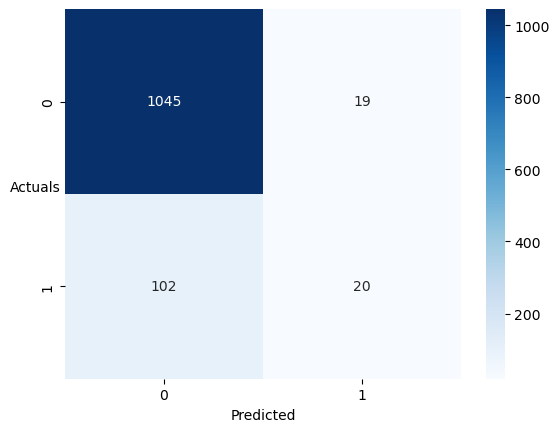

In [429]:
sns.heatmap((metrics.confusion_matrix(df3_train['Default'],y_class_pred)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [430]:
# Accuracy of Logit Model 3 without Optimization
(1045+20)/(1045+20+19+102)


0.8979763912310287

In [431]:
# Precision of Logit Model 3 without Optimization
20/(20+19)

0.5128205128205128

In [432]:
# Recall of Logit Model 3 without Optimization
20/(20+102)

0.16393442622950818

In [433]:
y_prob_pred_3 = model_3.predict()

In [434]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(df3_train['Default'],y_prob_pred_train)


In [435]:
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
optimal_threshold

0.15506718686745694

In [436]:
y_class_pred=[]
for i in range(0,len(y_prob_pred_train)):
    if np.array(y_prob_pred_train)[i]>0.155:
        a=1
    else:
        a=0
    y_class_pred.append(a)

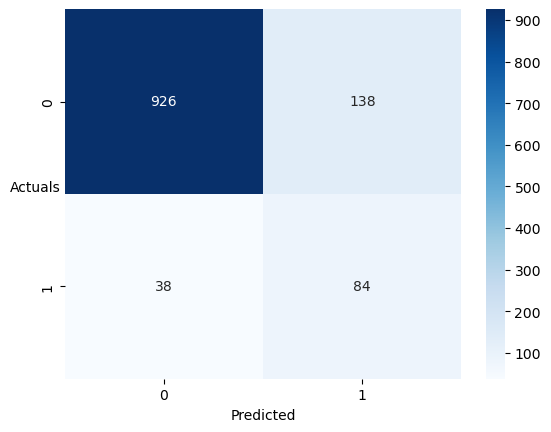

In [437]:
sns.heatmap((metrics.confusion_matrix(df3_train['Default'],y_class_pred)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [438]:
print(metrics.classification_report(df3_train['Default'],y_class_pred,digits=3))

              precision    recall  f1-score   support

           0      0.961     0.870     0.913      1064
           1      0.378     0.689     0.488       122

    accuracy                          0.852      1186
   macro avg      0.669     0.779     0.701      1186
weighted avg      0.901     0.852     0.870      1186



In [138]:
# AUC and ROC for the training data

# calculate AUC for training data
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score
# Predict probabilities on the train set
y_pred_prob = model_3.predict(sm.add_constant(X_train))
# Calculate the AUC score
auc_score = roc_auc_score(y_train, y_pred_prob)
print("AUC Score:", auc_score)

AUC Score: 0.8325835079502033


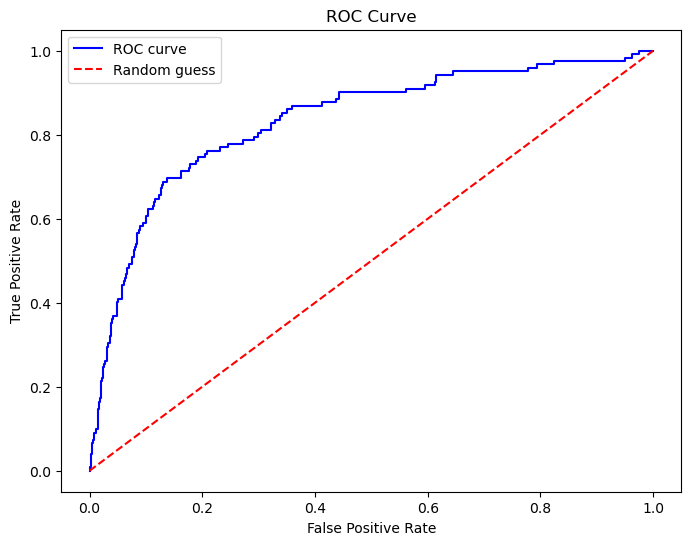

In [139]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_train, y_pred_prob)

# Plot ROC curve for train data
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC curve')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [140]:
# Validating on the test set
y_prob_pred_test = model_3.predict(df3_test)

In [141]:
y_class_pred=[]
for i in range(0,len(y_prob_pred_test)):
    if np.array(y_prob_pred_test)[i]>0.155:
        a=1
    else:
        a=0
    y_class_pred.append(a)

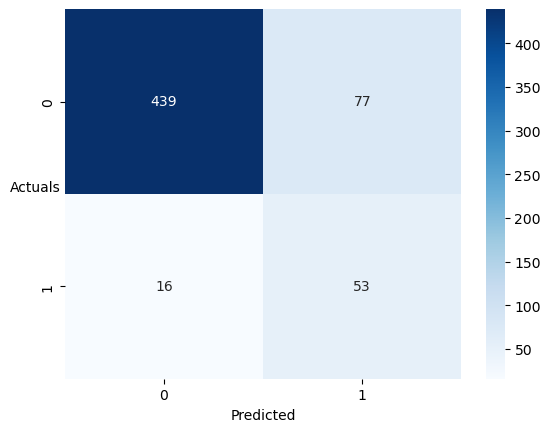

In [142]:
sns.heatmap((metrics.confusion_matrix(df3_test['Default'],y_class_pred)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [143]:
print(metrics.classification_report(df3_test['Default'],y_class_pred,digits=3))

              precision    recall  f1-score   support

           0      0.965     0.851     0.904       516
           1      0.408     0.768     0.533        69

    accuracy                          0.841       585
   macro avg      0.686     0.809     0.718       585
weighted avg      0.899     0.841     0.860       585



In [144]:
# AUC and ROC for the test data

# calculate AUC for test data
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score
# Predict probabilities on the test set
y_pred_prob = model_3.predict(sm.add_constant(X_test))
# Calculate the AUC score
auc_score = roc_auc_score(y_test, y_pred_prob)
print("AUC Score:", auc_score)

AUC Score: 0.8897595775755534


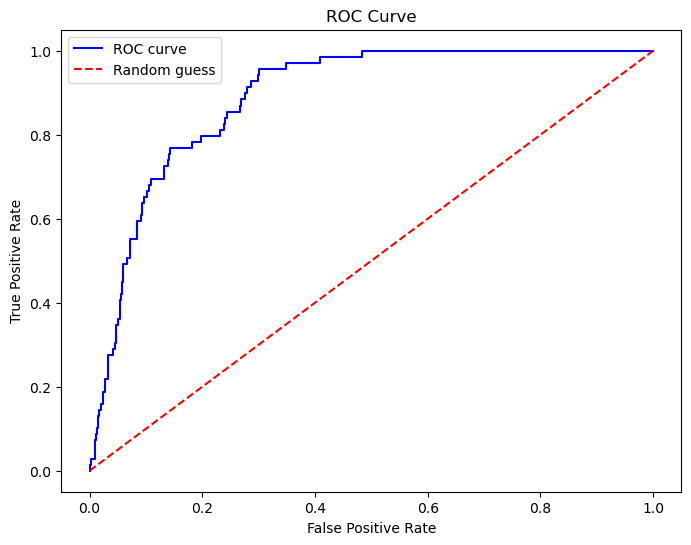

In [145]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Plot ROC curve for test data
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC curve')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [146]:
df3['Default'].value_counts()

0    1580
1     191
Name: Default, dtype: int64

In [147]:
# Get the coefficients
coefficients = model_3.params

print("Coefficients:", coefficients)

Coefficients: Intercept                         -3.343387e+00
Total_debt_to_Total_net_worth      1.353483e+02
Fixed_Assets_Turnover_Frequency    1.517181e+01
Tax_rate_A                        -5.779995e+00
RD_expense_rate                    1.730003e-10
Cash_Turnover_Rate                -1.513670e-10
dtype: float64


In [149]:
# Predict probabilities on the test set
y_pred_prob = model_3.predict(sm.add_constant(X_test))
pd.set_option('display.max_rows', None)
# Arrange the Series in descending order
y_pred_prob_sorted = y_pred_prob.sort_values(ascending=False)
print(y_pred_prob_sorted)


1073    0.726774
1873    0.700275
926     0.692208
238     0.691236
449     0.689500
605     0.684970
704     0.674362
466     0.657530
1644    0.637736
563     0.608078
1979    0.600640
1673    0.597042
209     0.596175
309     0.583195
637     0.580335
1884    0.579822
1720    0.578954
1103    0.575458
1974    0.572353
999     0.566772
1859    0.563503
1418    0.561068
434     0.557262
1682    0.556461
192     0.553520
1760    0.553158
1200    0.542859
729     0.540170
796     0.525741
1916    0.521192
1079    0.507394
202     0.503600
1985    0.500558
292     0.497743
505     0.475916
414     0.450861
177     0.445144
341     0.442690
1505    0.424414
1513    0.420569
265     0.415825
569     0.415560
1442    0.407453
257     0.398196
1788    0.394657
261     0.392234
802     0.391616
1759    0.379375
497     0.365174
218     0.359389
827     0.356606
1816    0.353414
1333    0.336694
2039    0.330506
79      0.330425
1496    0.327522
1332    0.322314
1601    0.314418
1282    0.3098

In [105]:
# Linear Descriminant Analysis

In [106]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

In [107]:
LDA = LinearDiscriminantAnalysis()

In [108]:
lda_model = LDA.fit(X_train, y_train)

In [109]:
pred_train_lda = lda_model.predict(X_train)
pred_test_lda = lda_model.predict(X_test)

In [110]:
print(metrics.classification_report(y_train, pred_train_lda))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      1064
           1       0.47      0.28      0.35       122

    accuracy                           0.89      1186
   macro avg       0.69      0.62      0.65      1186
weighted avg       0.87      0.89      0.88      1186



In [111]:
print(metrics.classification_report(y_test, pred_test_lda))

              precision    recall  f1-score   support

           0       0.92      0.95      0.93       516
           1       0.50      0.35      0.41        69

    accuracy                           0.88       585
   macro avg       0.71      0.65      0.67       585
weighted avg       0.87      0.88      0.87       585



In [112]:
pred_train_lda_prob = lda_model.predict_proba(X_train)[:,1]
pred_test_lda_prob = lda_model.predict_proba(X_test)[:,1]

In [113]:
fpr, tpr, thresholds = roc_curve(y_train,pred_train_lda_prob)

In [114]:
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
optimal_threshold

0.12086174467171922

In [115]:
y_class_pred=[]
for i in range(0,len(pred_train_lda_prob)):
    if np.array(pred_train_lda_prob)[i]>0.12:
        a=1
    else:
        a=0
    y_class_pred.append(a)

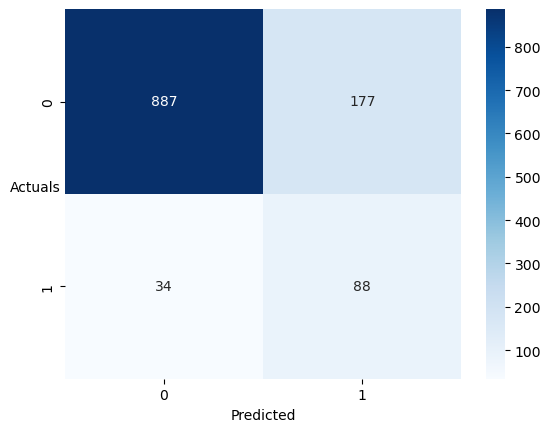

In [116]:
sns.heatmap((metrics.confusion_matrix(y_train,y_class_pred)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [117]:
print(metrics.classification_report(y_train, y_class_pred,digits=3))

              precision    recall  f1-score   support

           0      0.963     0.834     0.894      1064
           1      0.332     0.721     0.455       122

    accuracy                          0.822      1186
   macro avg      0.648     0.777     0.674      1186
weighted avg      0.898     0.822     0.849      1186



In [118]:
# AUC and ROC for the training data

# calculate AUC for training data
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score
# Predict probabilities on the train set
y_pred_prob = lda_model.predict(X_train)
# Calculate the AUC score
auc_score = roc_auc_score(y_train, y_pred_prob)
print("AUC Score:", auc_score)

AUC Score: 0.6210171946259091


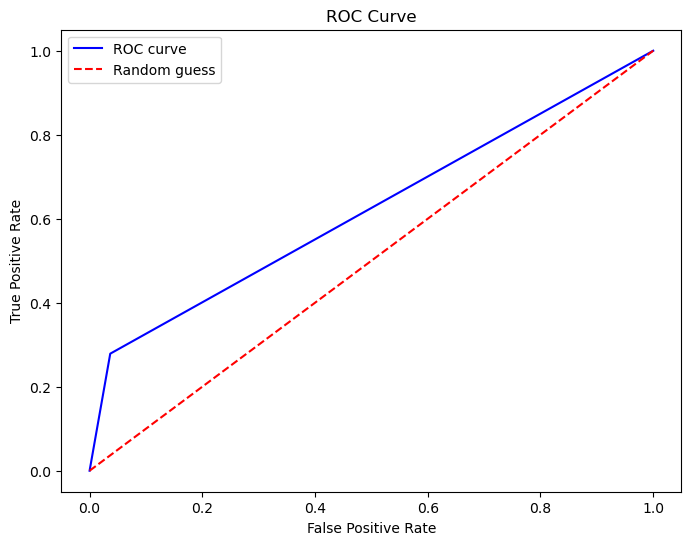

In [118]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_train, y_pred_prob)

# Plot ROC curve for train data
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC curve')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [150]:
y_class_pred=[]
for i in range(0,len(pred_test_lda_prob)):
    if np.array(pred_test_lda_prob)[i]>0.12:
        a=1
    else:
        a=0
    y_class_pred.append(a)

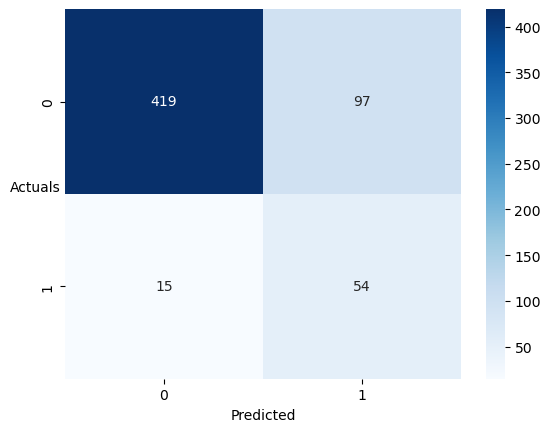

In [151]:
sns.heatmap((metrics.confusion_matrix(y_test, y_class_pred)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [152]:
print(metrics.classification_report(y_test, y_class_pred,digits=3))

              precision    recall  f1-score   support

           0      0.965     0.812     0.882       516
           1      0.358     0.783     0.491        69

    accuracy                          0.809       585
   macro avg      0.662     0.797     0.687       585
weighted avg      0.894     0.809     0.836       585



In [119]:
# AUC and ROC for the test data

# calculate AUC for test data
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score
# Predict probabilities on the test set
y_pred_prob = lda_model.predict(X_test)
# Calculate the AUC score
auc_score = roc_auc_score(y_test, y_pred_prob)
print("AUC Score:", auc_score)

AUC Score: 0.6506572295247726


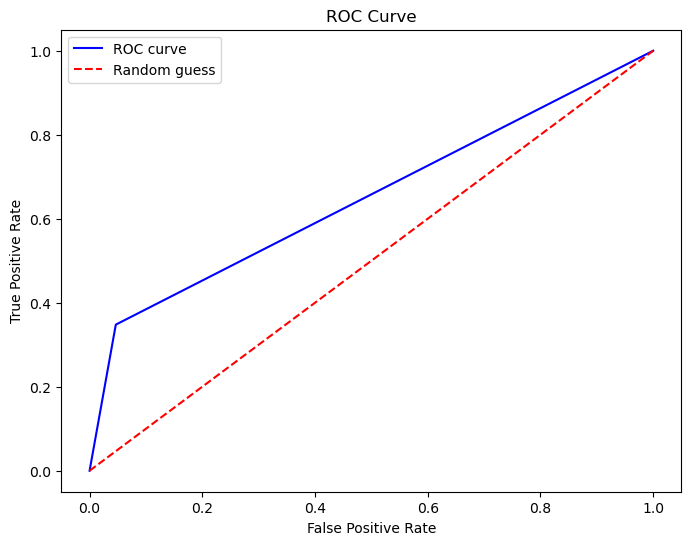

In [120]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Plot ROC curve for test data
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC curve')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [121]:
# Random Forest Classifier


In [122]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [5, 10, 15],
    'min_samples_split': [15, 30, 45],
    'n_estimators': [25, 50]
}

rfcl = RandomForestClassifier()

grid_search = GridSearchCV(estimator = rfcl, param_grid = param_grid)

In [123]:
grid_search.fit(X_train, y_train)

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'max_depth': [3, 5, 7],
                         'min_samples_leaf': [5, 10, 15],
                         'min_samples_split': [15, 30, 45],
                         'n_estimators': [25, 50]})

In [124]:
grid_search.best_params_

{'max_depth': 7,
 'min_samples_leaf': 15,
 'min_samples_split': 15,
 'n_estimators': 25}

In [125]:
best_grid = grid_search.best_estimator_

In [126]:
pred_train_rf = best_grid.predict(X_train)
pred_test_rf = best_grid.predict(X_test)

In [127]:
pred_train_rf = best_grid.predict(X_train)
pred_test_rf = best_grid.predict(X_test)

In [128]:
y_class_pred=[]
for i in range(0,len(pred_train_lda_prob)):
    if np.array(pred_train_lda_prob)[i]>0.28:
        a=1
    else:
        a=0
    y_class_pred.append(a)

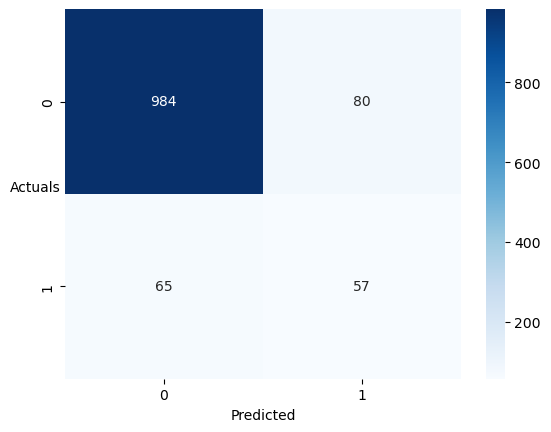

In [129]:
sns.heatmap((metrics.confusion_matrix(y_train,y_class_pred)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [130]:
print(metrics.classification_report(y_train, pred_train_rf))

              precision    recall  f1-score   support

           0       0.92      1.00      0.95      1064
           1       0.89      0.20      0.32       122

    accuracy                           0.91      1186
   macro avg       0.90      0.60      0.64      1186
weighted avg       0.91      0.91      0.89      1186



In [135]:
# AUC and ROC for the training data

# calculate AUC for training data
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score
# Predict probabilities on the train set
y_pred_prob = grid_search.predict(X_train)
# Calculate the AUC score
auc_score = roc_auc_score(y_train, y_pred_prob)
print("AUC Score:", auc_score)

AUC Score: 0.5969508813016147


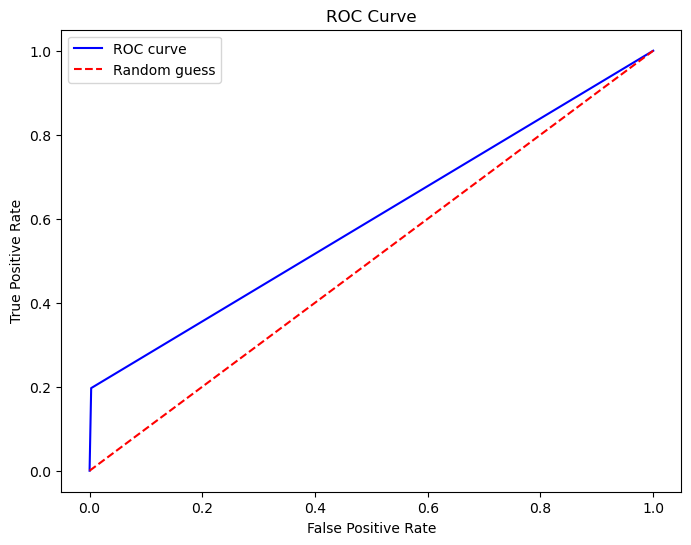

In [136]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_train, y_pred_prob)

# Plot ROC curve for train data
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC curve')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [131]:
y_class_pred=[]
for i in range(0,len(pred_test_lda_prob)):
    if np.array(pred_test_lda_prob)[i]>0.28:
        a=1
    else:
        a=0
    y_class_pred.append(a)

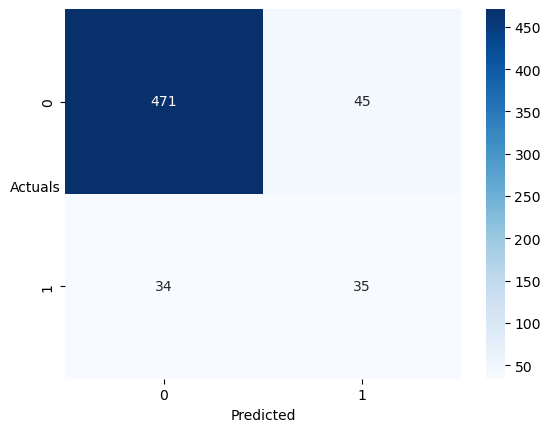

In [132]:
sns.heatmap((metrics.confusion_matrix(y_test, y_class_pred)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [133]:
print(metrics.classification_report(y_test, pred_test_rf))

              precision    recall  f1-score   support

           0       0.89      0.99      0.94       516
           1       0.50      0.09      0.15        69

    accuracy                           0.88       585
   macro avg       0.70      0.54      0.54       585
weighted avg       0.84      0.88      0.84       585



In [137]:
# AUC and ROC for the test data

# calculate AUC for test data
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score
# Predict probabilities on the test set
y_pred_prob = grid_search.predict(X_test)
# Calculate the AUC score
auc_score = roc_auc_score(y_test, y_pred_prob)
print("AUC Score:", auc_score)

AUC Score: 0.5376643073811931


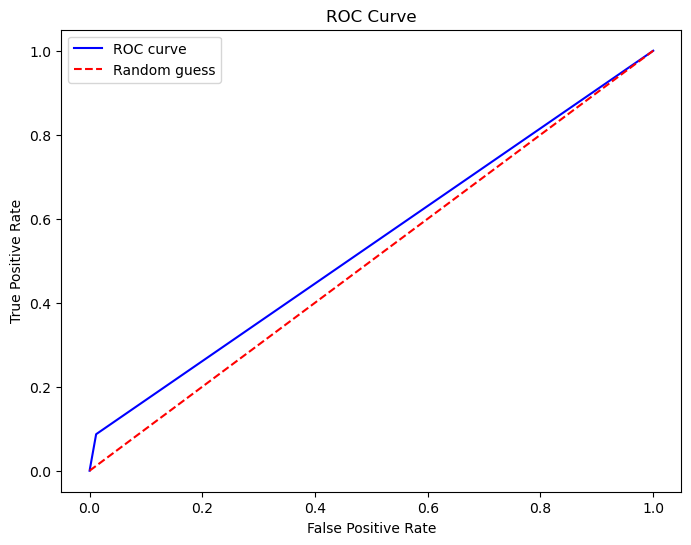

In [138]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Plot ROC curve for test data
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC curve')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [134]:
# Conclusion
# Among all the models tried in this case Logistic Regression with the best Recall backed by Precision is the best model aligned to our objective.